In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:

# AUV parameters 
m = 50.0          # kg
cd = 20.0         # drag coefficient

desired_depth = 10.0   # meters

In [16]:
# PID gains

Kp = 80
Ki = 1
Kd = 30

# Simulation settings
dt = 0.01
t_final = 50

time = np.arange(0, t_final + dt, dt)
N = len(time)

#   Initial conditions

z = 0.0          # depth
v = 0.0          # velocity

integral_error = 0.0
previous_error = 0.0

#arrays for data storage 

depth_history = np.zeros(N)
velocity_history = np.zeros(N)
thrust_history = np.zeros(N)
error_history = np.zeros(N)


In [17]:
for k in range(N):

    # Error
    error = desired_depth - z
    integral_error += error * dt
    derivative_error = (error - previous_error) / dt

    # PID controller
    thrust = (
        Kp * error
        + Ki * integral_error
        + Kd * derivative_error
    )

    # Ocean current disturbance
    current_force = 20 * np.sin(0.5 * time[k])

    # Drag force
    drag = cd * v

    # Vehicle dynamics
    acceleration = (thrust - drag + current_force) / m

    # Euler integration
    v = v + acceleration * dt
    z = z + v * dt

    # Store data
    depth_history[k] = z
    velocity_history[k] = v
    thrust_history[k] = thrust
    error_history[k] = error

    # Update previous error
    previous_error = error


In [18]:
# performance matrices
overshoot = (
    (np.max(depth_history) - desired_depth)
    / desired_depth
) * 100

steady_state_error = abs(
    desired_depth - depth_history[-1]
)

print("\nSimulation Complete")
print("-------------------")
print(f"Maximum Depth       : {np.max(depth_history):.2f} m")
print(f"Overshoot           : {overshoot:.2f} %")
print(f"Final Depth         : {depth_history[-1]:.2f} m")
print(f"Steady-State Error  : {steady_state_error:.4f} m")



Simulation Complete
-------------------
Maximum Depth       : 13.19 m
Overshoot           : 31.89 %
Final Depth         : 9.89 m
Steady-State Error  : 0.1103 m


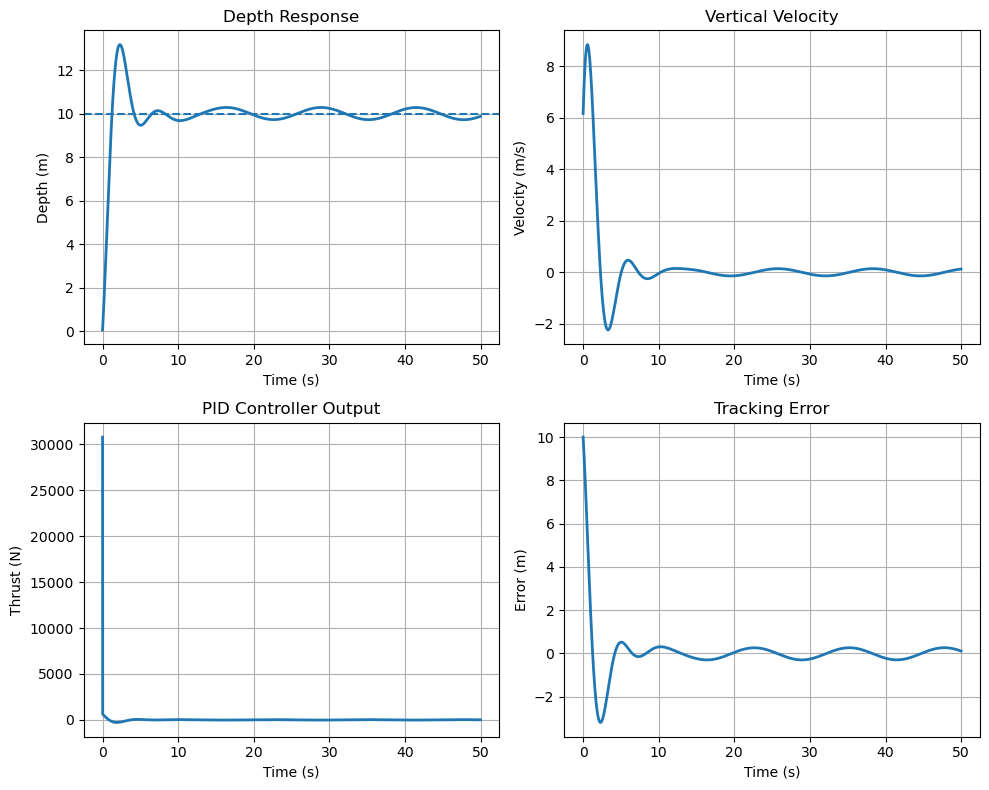

In [19]:
#plotting

plt.figure(figsize=(10, 8))

# Depth
plt.subplot(2, 2, 1)
plt.plot(time, depth_history, linewidth=2)
plt.axhline(
    desired_depth,
    linestyle='--'
)
plt.xlabel("Time (s)")
plt.ylabel("Depth (m)")
plt.title("Depth Response")
plt.grid(True)

# Velocity
plt.subplot(2, 2, 2)
plt.plot(time, velocity_history, linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Vertical Velocity")
plt.grid(True)

# Thrust
plt.subplot(2, 2, 3)
plt.plot(time, thrust_history, linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Thrust (N)")
plt.title("PID Controller Output")
plt.grid(True)

# Error
plt.subplot(2, 2, 4)
plt.plot(time, error_history, linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Error (m)")
plt.title("Tracking Error")
plt.grid(True)

plt.tight_layout()
plt.show()